# Neumonia Detection

Lucho Nov | 2024 <br>
Petit Fleur by Jill Barber

## 🧠 Clasificación de Neumonía con Rayos X Torácicos usando Deep Learning

En este proyecto paso a paso, te guiaré a través de todo el proceso: desde la carga del conjunto de datos **Mendeley Chest X-ray Pneumonia**, pasando por la **preparación de los datos**, la **construcción del modelo CNN**, su **entrenamiento**, y la **evaluación de los resultados** utilizando visualizaciones como **matrices de confusión** y **curvas de precisión/pérdida**.

> 🎯 ¡Este proyecto es perfecto para aprender sobre *deep learning* y clasificación de imágenes médicas!

---

### 🔍 Lo que aprenderás

- ✅ Cómo **preprocesar imágenes de rayos X** utilizando `ImageDataGenerator` para **aumentar los datos**
- ✅ Construcción de una **CNN con Keras**, utilizando capas como `Conv2D`, `MaxPooling2D`, `Dropout`, entre otras
- ✅ Entrenamiento del modelo con *callbacks* como `ReduceLROnPlateau`
- ✅ Visualización del rendimiento del modelo usando **Matplotlib** y **Seaborn**
- ✅ Análisis de predicciones mediante **informes de clasificación** y **muestras de imágenes predichas**

---

Dataset: https://data.mendeley.com/datasets/rscbjbr9sj/2

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import ReduceLROnPlateau
import os

## Import Dataset

In [2]:
labels = ['Pneumonia','Normal']
img_resize = 150

def get_data(dir):
  data = []
  for label in labels:
    path = os.path.join(dir, label)
    class_num = labels.index(label)

    for img in os.listdir(path):
      try:
        if img.endswith('jpeg'):
          img_arr = cv2.imread(os.path.join(path,img), cv2.IMREAD_GRAYSCALE)
          resized_arr = cv2.resize(img_arr, (img_resize, img_resize))
          data.append([resized_arr, class_num])
      except Exception as e:
        print(e)
  return np.array(data,dtype= 'object')


In [3]:
train = get_data(r'F:\Proyectos\chest_xray\train')
test = get_data(r'F:\Proyectos\chest_xray\test')
val = get_data(r'F:\Proyectos\chest_xray\val')

### Data Visualization & Preprocesamiento

<Axes: xlabel='count'>

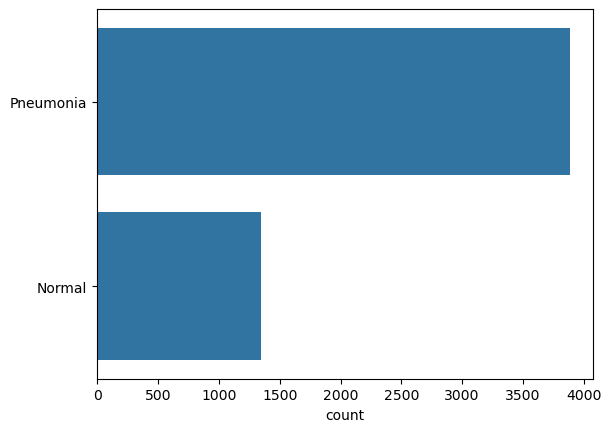

In [4]:
l = []
for i in train:
  if (i[1] == 0):
    l.append('Pneumonia')
  else:
    l.append('Normal')

sns.countplot(l)
     

Text(0.5, 1.0, 'Normal')

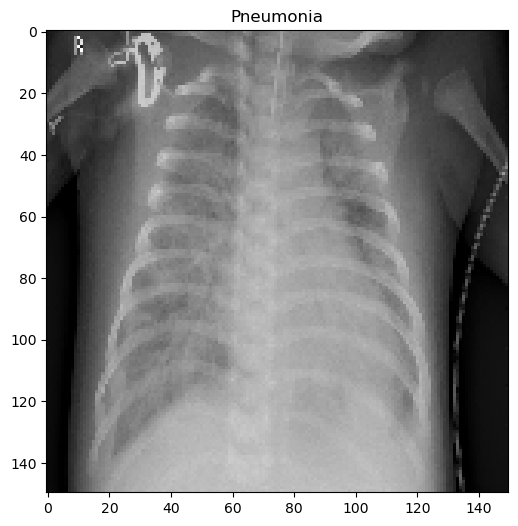

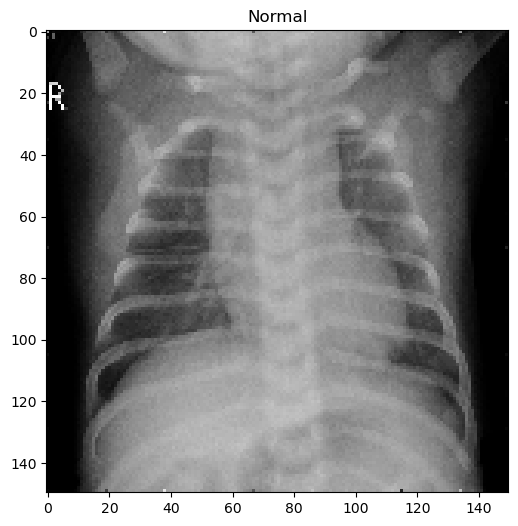

In [5]:
plt.figure(figsize=(6,6))

plt.imshow(train[0][0], cmap='gray')
plt.title(labels[train[0][1]])

plt.figure(figsize=(6,6))

plt.imshow(train[-11][0], cmap='gray')
plt.title(labels[train[-11][1]])
    

In [6]:
x_train = []
y_train = []

x_val = []
y_val = []

x_test = []
y_test = []

for feat, label in train:
  x_train.append(feat)
  y_train.append(label)

for feat,label in val:
  x_val.append(feat)
  y_val.append(label)

for feat, label in test:
  x_test.append(feat)
  y_test.append(label)
     

In [7]:
#Normalize the data
x_train = np.array(x_train)/255
x_val = np.array(x_val)/255
x_test = np.array(x_test)/255

In [8]:
x_train

array([[[0.07058824, 0.10980392, 0.11372549, ..., 0.05098039,
         0.02745098, 0.00392157],
        [0.08235294, 0.09411765, 0.11372549, ..., 0.05490196,
         0.03529412, 0.01176471],
        [0.08627451, 0.10196078, 0.1254902 , ..., 0.0627451 ,
         0.03529412, 0.00784314],
        ...,
        [0.03921569, 0.03529412, 0.03137255, ..., 0.05882353,
         0.05882353, 0.05882353],
        [0.03921569, 0.03921569, 0.03137255, ..., 0.05882353,
         0.05882353, 0.05882353],
        [0.03921569, 0.03921569, 0.03137255, ..., 0.05882353,
         0.05882353, 0.05882353]],

       [[0.23921569, 0.2745098 , 0.29803922, ..., 0.10980392,
         0.09803922, 0.08627451],
        [0.29411765, 0.31764706, 0.31372549, ..., 0.10980392,
         0.09411765, 0.09019608],
        [0.3372549 , 0.3254902 , 0.33333333, ..., 0.12156863,
         0.09019608, 0.08235294],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0. 

In [9]:
x_train = x_train.reshape(-1,img_resize, img_resize,1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1,img_resize,img_resize,1)
y_val = np.array(y_val)


x_test = x_test.reshape(-1,img_resize,img_resize,1)
y_test = np.array(y_test)

In [10]:
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=30,
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip=True,
    vertical_flip=False
)

datagen.fit(x_train)

### Training Model

In [11]:
model = Sequential()
model.add(Conv2D(32,(3,3), strides =1, padding='same', activation='relu', input_shape=(150,150,1)))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.1))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(64,(3,3), strides =1, padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(128,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Conv2D(256,(3,3), strides =1, padding='same', activation='relu'))
model.add(Dropout(0.2))
model.add(BatchNormalization())
model.add(MaxPool2D((2,2),strides=2,padding='same'))
model.add(Flatten())
model.add(Dense(units=128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))
model.compile(optimizer='rmsprop',loss='binary_crossentropy',metrics=['accuracy']) #rmsprop
model.summary()

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

In [12]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',patience=2,verbose=1,factor=0.3,min_lr=0.000001)

In [13]:
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")

x_val shape: (624, 150, 150, 1)
y_val shape: (624,)


In [14]:
history = model.fit(x_train,y_train,batch_size=32,epochs=18,
                    validation_data=datagen.flow(x_val,y_val),
                    callbacks=[learning_rate_reduction])

Epoch 1/18
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 879ms/step - accuracy: 0.8436 - loss: 0.7466

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


164/164 ━━━━━━━━━━━━━━━━━━━━ 154s 903ms/step - accuracy: 0.8972 - loss: 0.3486 - val_accuracy: 0.6250 - val_loss: 22.5407 - learning_rate: 0.0010
Epoch 2/18
164/164 ━━━━━━━━━━━━━━━━━━━━ 142s 869ms/step - accuracy: 0.9558 - loss: 0.1249 - val_accuracy: 0.6250 - val_loss: 32.4419 - learning_rate: 0.0010
Epoch 3/18
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 975ms/step - accuracy: 0.9694 - loss: 0.0936
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
164/164 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9694 - loss: 0.0906 - val_accuracy: 0.6250 - val_loss: 32.9253 - learning_rate: 0.0010
Epoch 4/18
164/164 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.9851 - loss: 0.0375 - val_accuracy: 0.6266 - val_loss: 15.1944 - learning_rate: 3.0000e-04
Epoch 5/18
164/164 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9918 - loss: 0.0231 - val_accuracy: 0.6442 - val_loss: 8.9094 - learning_rate: 3.0000e-04
Epoch 6/18
164/164 ━━━━━━━━━━━━━━━━━━━━ 142s 863ms/step - accuracy: 0.9948 

In [15]:
model.evaluate(x_test,y_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.7372 - loss: 3.7436


[3.7436320781707764, 0.7371794581413269]

In [16]:
print(f"La pérdida del modelo es {model.evaluate(x_test, y_test)[0]}")
print(f"La precisión del modelo es {model.evaluate(x_test, y_test)[1] * 100} %")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.7372 - loss: 3.7436
La pérdida del modelo es 3.7436320781707764
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.7372 - loss: 3.7436
La precisión del modelo es 73.71794581413269 %


### Analisis de Perfomance

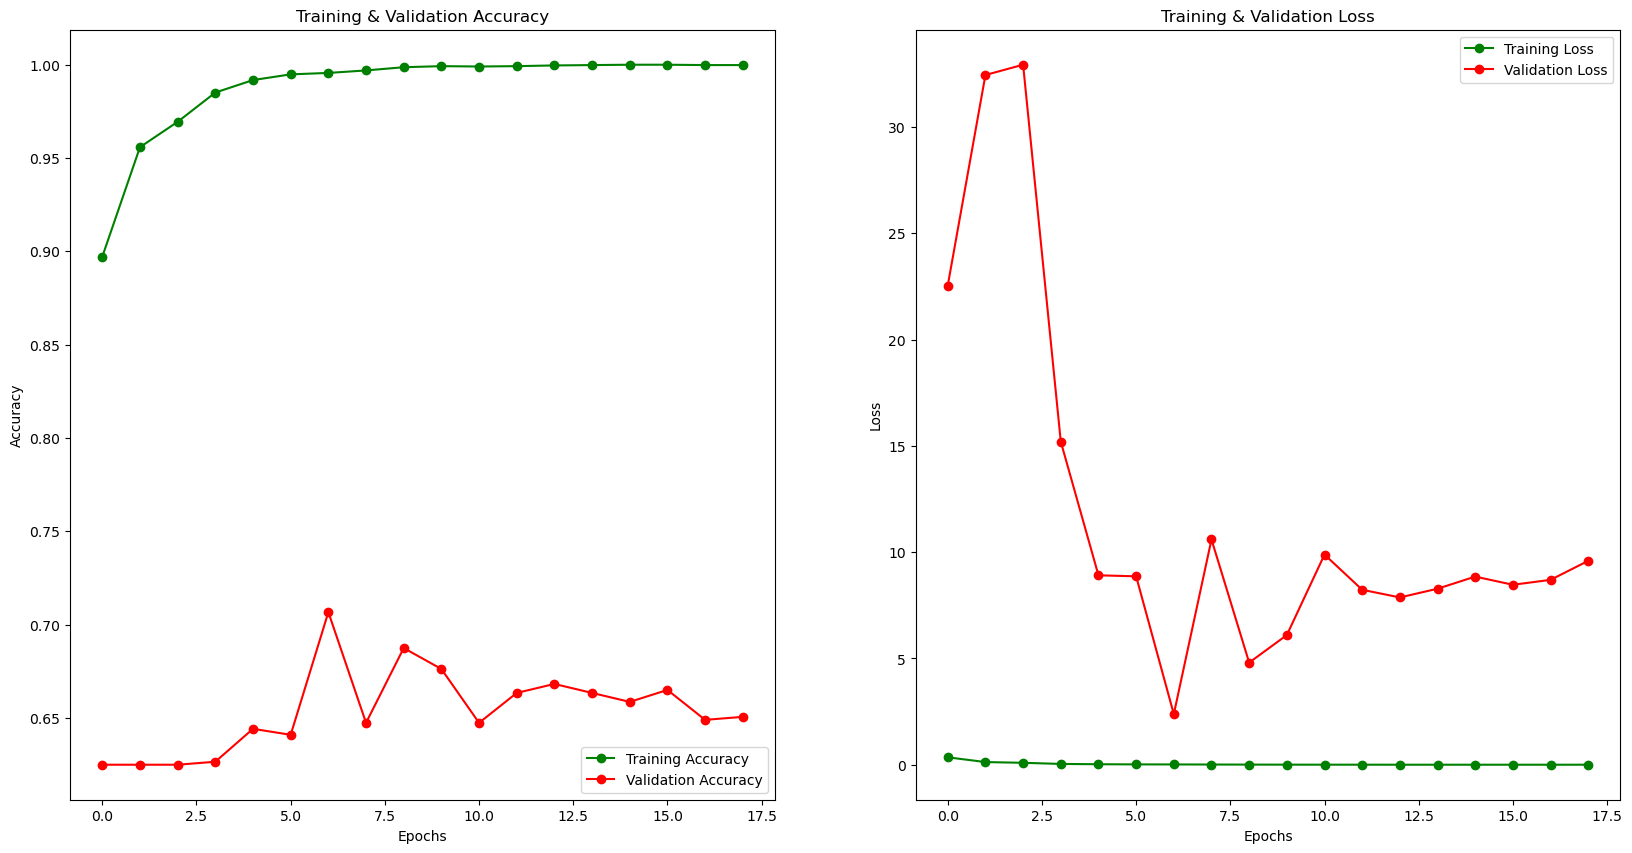

In [17]:
epochs = [i for i in range(18)]
fig, ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

fig.set_size_inches(20,10)

ax[0].plot(epochs, train_acc, 'go-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')


ax[1].plot(epochs, train_loss, 'g-o', label='Training Loss')
ax[1].plot(epochs, val_loss, 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
plt.show()

In [18]:
predictions = (model.predict(x_test) > 0.5).astype('int32')
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
print(classification_report(y_test, predictions, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.70      1.00      0.83       390
   Normal (Class 1)       1.00      0.30      0.46       234

           accuracy                           0.74       624
          macro avg       0.85      0.65      0.64       624
       weighted avg       0.81      0.74      0.69       624



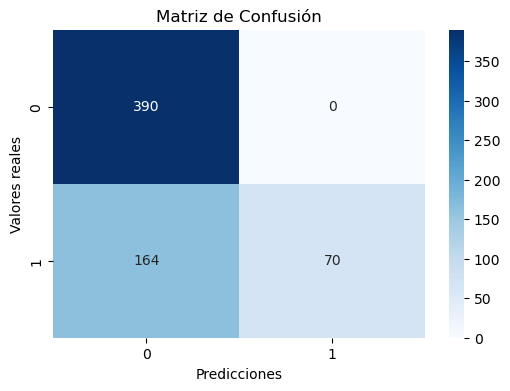

In [20]:
# Calcula la matriz de confusión
cm = confusion_matrix(y_test, predictions)

# Grafica con Seaborn
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de Confusión')
plt.show()

In [21]:
correct = np.nonzero(predictions == y_test)[0]
incorrect = np.nonzero(predictions != y_test)[0]

### Algunas clases bien predecidas

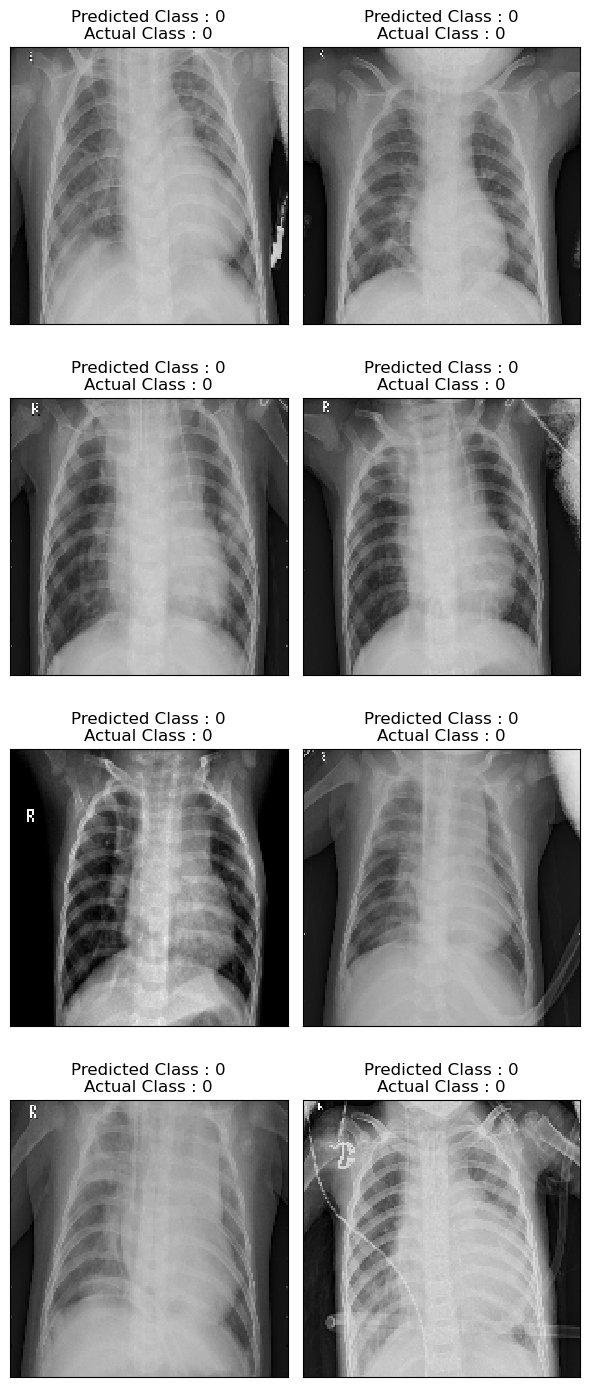

In [22]:
i = 0
plt.figure(figsize=(6,15))
for c in correct[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1

### Algunas clases mal predecidas

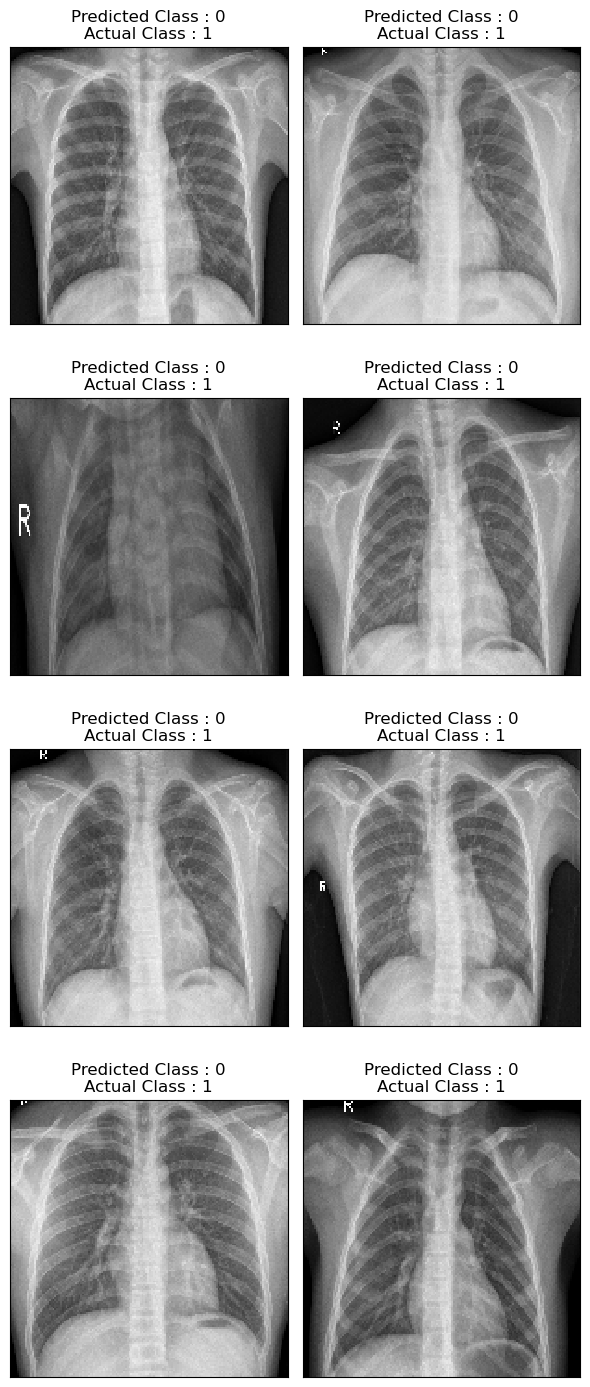

In [23]:
i = 0
plt.figure(figsize=(6,15))
for c in incorrect[10:18]:
  plt.subplot(4,2,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_test[c].reshape(150,150), cmap='gray', interpolation='none')
  plt.title(f"Predicted Class : {predictions[c]}\nActual Class : {y_test[c]}")
  plt.tight_layout()
  i += 1